# SHL Grammar Scoring: Model

Predicts the grammar score (1 to 5) of each test clip from the features made in the feature extraction notebook.

Five simple models, blended with a weighted average:

| Model | Input | What it sees |
|---|---|---|
| SVR | WavLM layer 21 (mean over time) | the audio |
| SVR | Whisper encoder layer 31 (mean and std over time) | the audio, at the level of words |
| Ridge | RoBERTa layer 19 | the transcript |
| Ridge | Qwen2.5-1.5B layer 17 | the transcript |
| Ridge | handcrafted features | syntax, grammar errors, acceptability, timing |

Runs on CPU in about 10 minutes (most of it is the layer scan in section 2).

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeCV
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

warnings.filterwarnings("ignore")

DATA_DIR = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"
FEATURES_DIR = "/kaggle/input/datasets/codewiz19/features-shl"  # output of the feature extraction notebook
OUT_DIR = "/kaggle/working"
SEEDS = [0, 1, 2]

BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#9a9a9a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e5e5e5", "axes.axisbelow": True, "font.size": 10,
                     "axes.titleweight": "bold", "axes.titlelocation": "left"})

## 1. Load the data

In [2]:
clips = pd.read_csv(f"{FEATURES_DIR}/clips.csv")
features = pd.read_csv(f"{FEATURES_DIR}/features.csv")
emb = {name: np.load(f"{FEATURES_DIR}/emb_{name}.npy", mmap_mode="r") for name in ("wavlm", "whisper", "roberta", "qwen")}

is_test = clips["split"].eq("test").to_numpy()
# 37 training clips are labelled 0: pure noise that the raters could not score, so we leave them out
is_train = clips["split"].eq("train").to_numpy() & (clips["label"] > 0).to_numpy()
y = clips.loc[is_train, "label"].to_numpy()

print(f"train {is_train.sum()} | test {is_test.sum()} | label mean {y.mean():.2f}, std {y.std():.3f}")
print({name: e.shape for name, e in emb.items()})

train 732 | test 216 | label mean 3.48, std 1.014
{'wavlm': (985, 25, 2048), 'whisper': (985, 33, 2560), 'roberta': (985, 25, 1024), 'qwen': (985, 29, 1536)}


The scores come in half steps. Most speakers score 3 to 5; very low scores are rare, which makes them the hardest to predict. The bars at 0 are the noise clips we drop.

Always predicting the average score would give an RMSE of 1.014 (the standard deviation of the labels). That is the baseline every model has to beat.

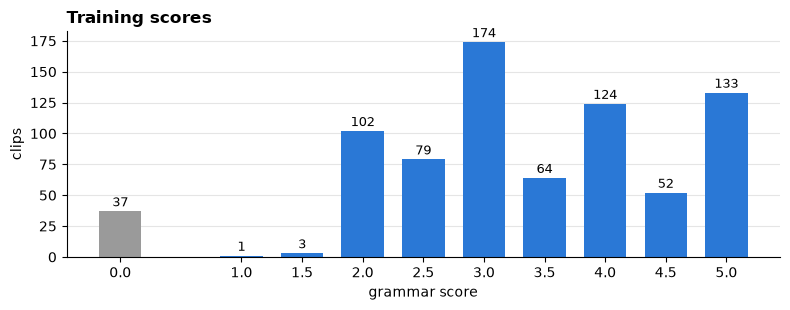

In [3]:
counts = clips.loc[clips["split"].eq("train"), "label"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(counts.index, counts.values, width=0.35, color=[GREY if s == 0 else BLUE for s in counts.index])
for s, n in counts.items():
    ax.text(s, n + 4, n, ha="center", fontsize=9)
ax.set(title="Training scores", xlabel="grammar score", ylabel="clips", xticks=counts.index)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

## 2. Which layer of each embedding?

Each embedding model has 25 to 33 layers, and different layers capture different things (lower ones the sound, higher ones the words). For every layer we fit a Ridge model and measure its cross-validated RMSE. The chosen layer is the lowest point of each curve.

Both audio models are best in their last layers, where they represent words rather than raw sound. Both text models are best around two thirds of the way up.

In [4]:
def svr():
    return make_pipeline(StandardScaler(), SVR(C=10, epsilon=0.1))


def ridge():
    # the imputer fills the few missing handcrafted features (e.g. transcripts without punctuation)
    return make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), RidgeCV(alphas=np.logspace(-1, 6, 15)))


def rmse(pred):
    return np.sqrt(np.mean((np.clip(pred, 1, 5) - y) ** 2))


strata = np.clip(np.round(y), 2, 5).astype(int)  # stratify by score level (1 and 1.5 are rare, so merged into 2)
scan_folds = list(StratifiedKFold(5, shuffle=True, random_state=0).split(y, strata))


def layer_rmse(x):
    pred = np.zeros(len(y))
    for tr, va in scan_folds:
        pred[va] = ridge().fit(x[tr], y[tr]).predict(x[va])
    return rmse(pred)


SCAN = {  # name: (embedding, which part of the vector, chosen layer)
    "WavLM": ("wavlm", slice(0, 1024), 21),
    "Whisper encoder": ("whisper", slice(None), 31),
    "RoBERTa": ("roberta", slice(None), 19),
    "Qwen": ("qwen", slice(None), 17),
}
scan = {}
for name, (key, dims, _) in SCAN.items():
    scan[name] = [layer_rmse(np.asarray(emb[key][is_train, i, dims], dtype=np.float32)) for i in range(emb[key].shape[1])]
    print(f"{name:<16} best layer {int(np.argmin(scan[name]))}: RMSE {min(scan[name]):.4f}")

WavLM            best layer 21: RMSE 0.5421


Whisper encoder  best layer 31: RMSE 0.5382


RoBERTa          best layer 19: RMSE 0.6010


Qwen             best layer 17: RMSE 0.6038


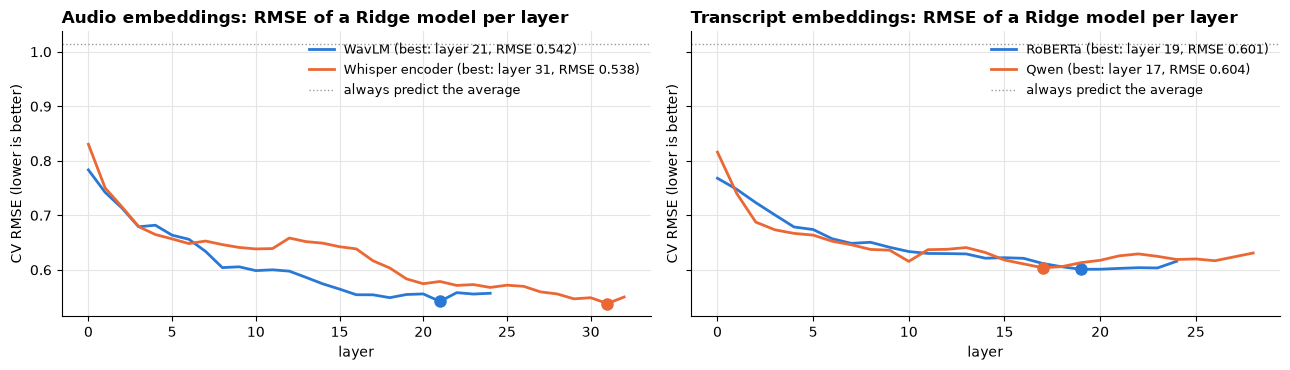

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
for ax, names, title in [(axes[0], ["WavLM", "Whisper encoder"], "Audio embeddings"),
                         (axes[1], ["RoBERTa", "Qwen"], "Transcript embeddings")]:
    for name, color in zip(names, [BLUE, ORANGE]):
        best = SCAN[name][2]
        ax.plot(scan[name], color=color, lw=2, label=f"{name} (best: layer {best}, RMSE {scan[name][best]:.3f})")
        ax.plot(best, scan[name][best], "o", ms=8, color=color)
    ax.axhline(y.std(), color=GREY, ls=":", lw=1, label="always predict the average")
    ax.set(title=f"{title}: RMSE of a Ridge model per layer", xlabel="layer", ylabel="CV RMSE (lower is better)")
    ax.legend(frameon=False, fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

## 3. Which handcrafted features carry signal?

Spearman correlation of each handcrafted feature with the score (top 15). Blue: higher value means a higher score; orange: higher value means a lower score.

The strongest signals are what we would expect from a grammar rubric: how grammatical the sentences look to the CoLA classifier, vocabulary variety, and how much the two transcripts disagree (hard-to-follow speech).

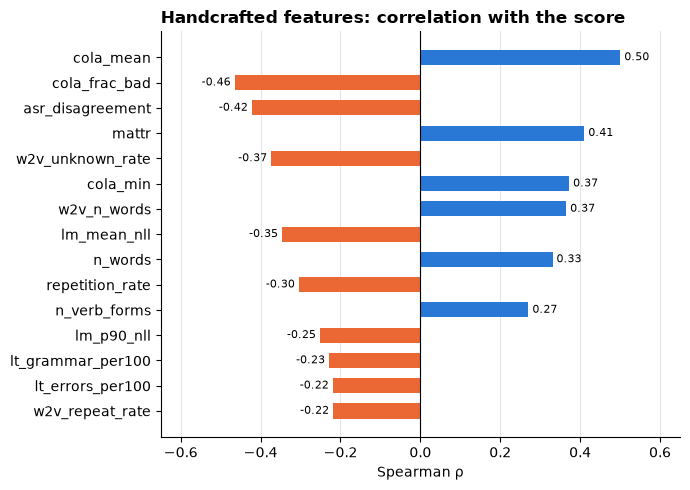

In [6]:
rho = features[is_train].apply(lambda col: spearmanr(col, y, nan_policy="omit")[0])
top = rho.reindex(rho.abs().sort_values().index).tail(15)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top.index, top.values, height=0.6, color=[BLUE if v > 0 else ORANGE for v in top.values])
for i, v in enumerate(top.values):
    ax.text(v + (0.01 if v > 0 else -0.01), i, f"{v:.2f}", va="center", ha="left" if v > 0 else "right", fontsize=8)
ax.axvline(0, color="black", lw=0.8)
ax.set(title="Handcrafted features: correlation with the score", xlabel="Spearman ρ", xlim=(-0.65, 0.65))
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 4. Train the five models

5-fold cross-validation, repeated with 3 different shuffles. Every training clip gets an out-of-fold prediction (from models that never saw it), which gives an honest score. The test prediction is the average of all 15 fitted models.

In [7]:
def layer(key, i, dims=slice(None)):
    return np.asarray(emb[key][:, i, dims], dtype=np.float32)


X = {
    "SVR · WavLM": layer("wavlm", 21, slice(0, 1024)),  # first half of the vector is the mean
    "SVR · Whisper": layer("whisper", 31),              # mean and std
    "Ridge · RoBERTa": layer("roberta", 19),
    "Ridge · Qwen": layer("qwen", 17),
    "Ridge · features": features.to_numpy(np.float32),
}
MODELS = {name: svr if name.startswith("SVR") else ridge for name in X}

oof = {name: np.zeros(len(y)) for name in MODELS}
test = {name: np.zeros(is_test.sum()) for name in MODELS}

for seed in SEEDS:
    for tr, va in StratifiedKFold(5, shuffle=True, random_state=seed).split(y, strata):
        for name, make_model in MODELS.items():
            x_train = X[name][is_train]
            model = make_model().fit(x_train[tr], y[tr])
            oof[name][va] += model.predict(x_train[va]) / len(SEEDS)
            test[name] += model.predict(X[name][is_test]) / (len(SEEDS) * 5)

for name in MODELS:
    print(f"{name:<17} CV RMSE {rmse(oof[name]):.4f}")

SVR · WavLM       CV RMSE 0.5213
SVR · Whisper     CV RMSE 0.5270
Ridge · RoBERTa   CV RMSE 0.6022
Ridge · Qwen      CV RMSE 0.6056
Ridge · features  CV RMSE 0.7056


## 5. Blend

A linear regression on the five out-of-fold predictions, with weights forced to be non-negative, decides how much each model counts. Its own score is measured with a separate cross-validation, so the blend is also judged on clips it did not see.

In [8]:
L = np.column_stack(list(oof.values()))
L_test = np.column_stack(list(test.values()))

blend_oof = np.zeros(len(y))
for tr, va in StratifiedKFold(5, shuffle=True, random_state=99).split(y, strata):
    blend_oof[va] = LinearRegression(positive=True).fit(L[tr], y[tr]).predict(L[va])

blender = LinearRegression(positive=True).fit(L, y)
weights = pd.Series(blender.coef_, index=list(MODELS))
final_test = np.clip(blender.predict(L_test), 1, 5)

print(f"blend            CV RMSE {rmse(blend_oof):.4f}")
print(f"predict the mean CV RMSE {y.std():.4f}")
print("weights:", weights.round(3).to_dict())

blend            CV RMSE 0.4783
predict the mean CV RMSE 1.0137
weights: {'SVR · WavLM': 0.473, 'SVR · Whisper': 0.298, 'Ridge · RoBERTa': 0.152, 'Ridge · Qwen': 0.154, 'Ridge · features': 0.109}


Each model alone is clearly worse than the blend: the audio and text models make different mistakes, so they correct each other. The audio models get most of the weight, even though only grammar is scored: they hear what was actually said, before speech recognition tidies it up.

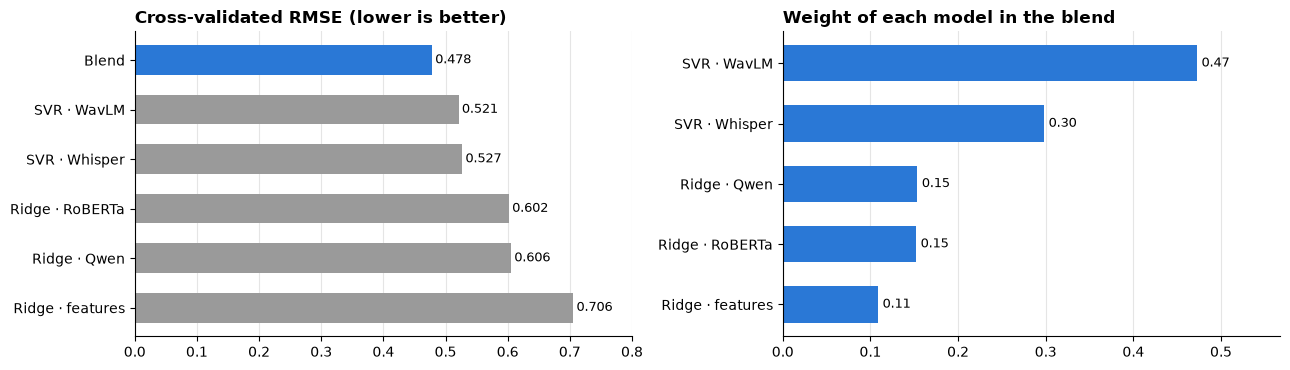

In [9]:
scores = pd.Series({name: rmse(p) for name, p in oof.items()} | {"Blend": rmse(blend_oof)}).sort_values(ascending=False)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.8))

ax1.barh(scores.index, scores.values, height=0.6, color=[BLUE if n == "Blend" else GREY for n in scores.index])
for i, v in enumerate(scores.values):
    ax1.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
ax1.set(title="Cross-validated RMSE (lower is better)", xlim=(0, 0.8))
ax1.grid(axis="y", visible=False)

w = weights.sort_values()
ax2.barh(w.index, w.values, height=0.6, color=BLUE)
for i, v in enumerate(w.values):
    ax2.text(v + 0.005, i, f"{v:.2f}", va="center", fontsize=9)
ax2.set(title="Weight of each model in the blend", xlim=(0, w.max() * 1.2))
ax2.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 6. Where the model goes wrong

Left: out-of-fold prediction against the true score (with a little horizontal jitter so the points don't overlap). Right: the error at each score level.

The model is cautious at the extremes: clips scored 1 or 2 are predicted too high, and clips scored 5 slightly too low. This is typical when there are few examples at the ends of the scale.

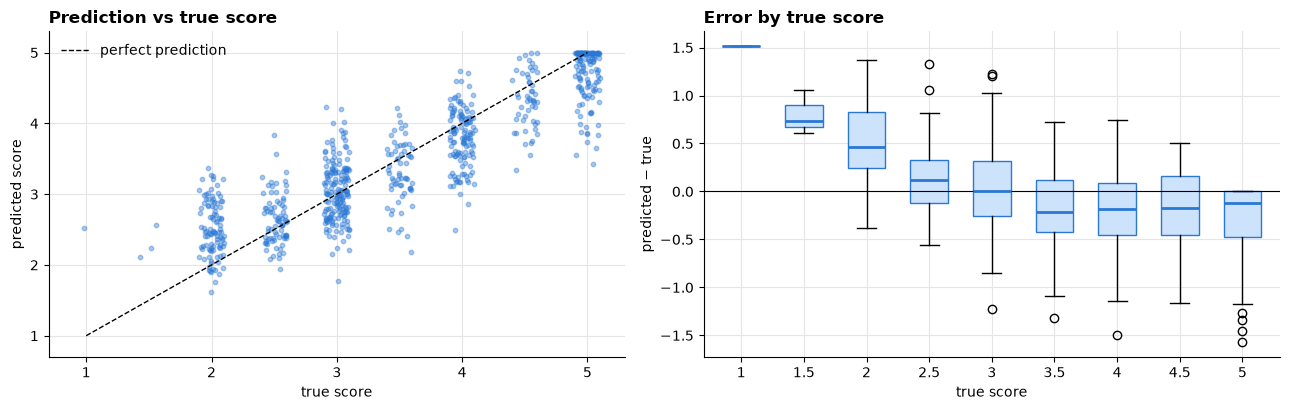

within 0.5 of the true score: 74% | within 1.0: 95%


In [10]:
pred = np.clip(blend_oof, 1, 5)
levels = np.sort(np.unique(y))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))

jitter = np.random.default_rng(0).uniform(-0.1, 0.1, len(y))
ax1.scatter(y + jitter, pred, s=10, alpha=0.4, color=BLUE)
ax1.plot([1, 5], [1, 5], "k--", lw=1, label="perfect prediction")
ax1.set(title="Prediction vs true score", xlabel="true score", ylabel="predicted score", xlim=(0.7, 5.3), ylim=(0.7, 5.3))
ax1.legend(frameon=False)

ax2.boxplot([pred[y == lv] - lv for lv in levels], positions=levels, widths=0.3, patch_artist=True,
            boxprops=dict(facecolor="#cde2fb", edgecolor=BLUE), medianprops=dict(color=BLUE, lw=2))
ax2.axhline(0, color="black", lw=0.8)
ax2.set(title="Error by true score", xlabel="true score", ylabel="predicted − true", xlim=(0.7, 5.3))
ax2.set_xticks(levels, [f"{lv:g}" for lv in levels])
plt.tight_layout()
plt.show()

print(f"within 0.5 of the true score: {np.mean(np.abs(pred - y) <= 0.5):.0%} | within 1.0: {np.mean(np.abs(pred - y) <= 1.0):.0%}")

## 7. Is the test set like the training set?

A quick check: train a classifier to tell training clips from test clips. If the two sets were alike, it could not do better than chance (AUC 0.5).

It can (AUC around 0.8), so the test clips differ from the training clips, both in the audio and in what is said. Cross-validation only measures performance on clips like the training ones, so small cross-validation gains did not always carry over to the leaderboard. That is why the final choice between close versions was made on the Kaggle score.

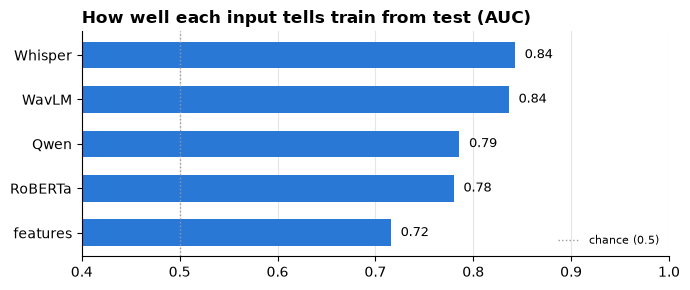

In [11]:
keep = is_train | is_test
in_test = is_test[keep]
auc = {}
for name in MODELS:
    p = cross_val_predict(make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), LogisticRegression(C=0.01, max_iter=2000)),
                          X[name][keep], in_test, cv=StratifiedKFold(5, shuffle=True, random_state=0), method="predict_proba")[:, 1]
    auc[name.split(" · ")[1]] = roc_auc_score(in_test, p)
auc = pd.Series(auc).sort_values()

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(auc.index, auc.values, height=0.6, color=BLUE)
for i, v in enumerate(auc.values):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9)
ax.axvline(0.5, color=GREY, ls=":", lw=1, label="chance (0.5)")
ax.set(title="How well each input tells train from test (AUC)", xlim=(0.4, 1))
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 8. Submission

In [12]:
submission = pd.DataFrame({"filename": clips.loc[is_test, "filename"].to_numpy(), "label": final_test})
assert submission["filename"].tolist() == pd.read_csv(f"{DATA_DIR}/test.csv")["filename"].tolist()
submission.to_csv(f"{OUT_DIR}/submission.csv", index=False)

print(f"{len(submission)} rows | mean {final_test.mean():.3f} | std {final_test.std():.3f}")
submission.head()

216 rows | mean 3.283 | std 0.827


,filename,label
0,audio_128.wav,2.933876
1,audio_156.wav,4.491688
2,audio_19.wav,4.587896
3,audio_108.wav,1.942970
4,audio_206.wav,2.257807
